# Deep Crossentropy method

In this section we'll extend your CEM implementation with neural networks! You will train a multi-layer neural network to solve simple continuous state space games. __Please make sure you're done with tabular crossentropy method from the previous notebook.__

![img](https://watanimg.elwatannews.com/old_news_images/large/249765_Large_20140709045740_11.jpg)



In [3]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

In [4]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from gymnasium.wrappers import RecordVideo
from itertools import chain
from collections import deque
from joblib import Parallel, delayed
from IPython.display import clear_output

%matplotlib inline

state vector dim = 4
n_actions = 2


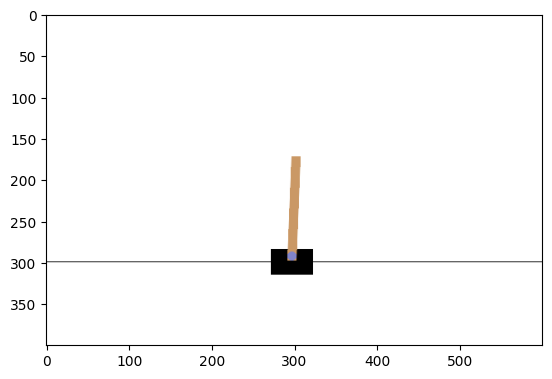

In [3]:
# if you see "<classname> has no attribute .env", remove .env or update gym
env = gym.make("CartPole-v1", render_mode="rgb_array").env

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("n_actions =", n_actions)

env.close()

In [21]:
def save_agent(agent, path):
    from pickle import dump
    with open(path, 'wb') as f:
        dump(agent, f)

# Neural Network Policy

For this assignment we'll utilize the simplified neural network implementation from __[Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)__. Here's what you'll need:

* `agent.partial_fit(states, actions)` - make a single training pass over the data. Maximize the probability of :actions: from :states:
* `agent.predict_proba(states)` - predict probabilities of all actions, a matrix of shape __[len(states), n_actions]__


In [5]:
agent = MLPClassifier(
    hidden_layer_sizes=(20, 20),
    activation="tanh",
)

# initialize agent to the dimension of state space and number of actions
agent.partial_fit([env.reset()[0]] * n_actions, np.arange(n_actions), classes=np.arange(n_actions))

agent.predict_proba([env.reset()[0]]), n_actions

(array([[0.29077036, 0.70922964]]), np.int64(2))

In [1]:
def generate_session(env, agent, t_max=2000):
    """
    Play a single game using agent neural network.
    Terminate when game finishes or after :t_max: steps
    """
    states, actions = [], []
    total_reward = 0

    s, _ = env.reset()

    for t in range(t_max):

        # use agent to predict a vector of action probabilities for state :s:
        probs = agent.predict_proba([s])[0]

        assert probs.shape == (env.action_space.n,), "make sure probabilities are a vector (hint: np.reshape)"

        # use the probabilities you predicted to pick an action
        # sample proportionally to the probabilities, don't just take the most likely action
        a = np.random.choice(env.action_space.n, p=probs)
        # ^-- hint: try np.random.choice

        new_s, r, terminated, truncated, _ = env.step(a)

        # record sessions like you did before
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward


In [7]:
dummy_states, dummy_actions, dummy_reward = generate_session(env, agent, t_max=5)
print("states:", np.stack(dummy_states))
print("actions:", dummy_actions)
print("reward:", dummy_reward)


states: [[-0.00653476 -0.01378856 -0.04842056  0.01779537]
 [-0.00681053 -0.20818387 -0.04806465  0.2948165 ]
 [-0.0109742  -0.0124108  -0.04216832 -0.01262953]
 [-0.01122242 -0.20690343 -0.04242091  0.26645625]
 [-0.01536049 -0.01120252 -0.03709178 -0.03929903]]
actions: [0, 1, 0, 1, 1]
reward: 5.0


### CEM steps
Deep CEM uses exactly the same strategy as the regular CEM, so you can copy your function code from previous notebook.

The only difference is that now each observation is not a number but a `float32` vector.

In [8]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=50, strict=False):
    rewards_treshold = np.percentile(rewards_batch, percentile)
    elite_states = []
    elite_actions = []
    for states, actions, reward in zip(states_batch, actions_batch, rewards_batch):
        if reward >= rewards_treshold and strict == False:
            elite_states.extend(states)
            elite_actions.extend(actions)
        elif reward > rewards_treshold and strict == True:
            elite_states.extend(states)
            elite_actions.extend(actions)
    
    return elite_states, elite_actions


# Training loop
Generate sessions, select N best and fit to those.

In [ ]:
def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()

    plt.show()


mean reward = 195.780, threshold=218.300


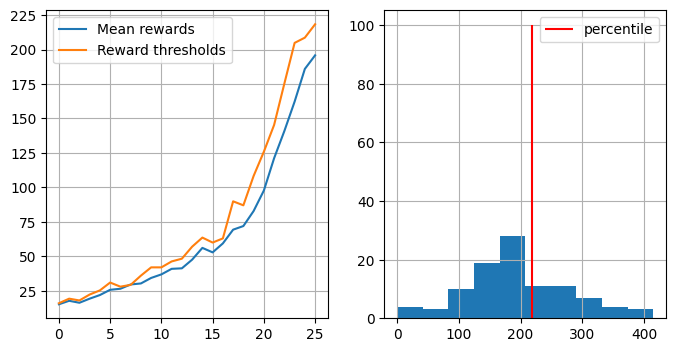

You Win! You may stop training now via KeyboardInterrupt.


In [10]:
n_sessions = 100
percentile = 70
log = []

for i in range(100):
    sessions = [generate_session(env, agent) for _ in range(n_sessions)]

    states_batch, actions_batch, rewards_batch = zip(*sessions)

    elite_states, elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, percentile
    )

    agent.partial_fit(elite_states, elite_actions)

    show_progress(
        rewards_batch, log, percentile, reward_range=[0, np.max(rewards_batch)]
    )

    if np.mean(rewards_batch) > 190:
        print("You Win! You may stop training now via KeyboardInterrupt.")
        break

save_agent(agent, "cartpole-v1_mlp.pkl")

# Results

In [11]:
with RecordVideo(
    env=gym.make("CartPole-v1", render_mode="rgb_array"),
    video_folder="./videos",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent) for _ in range(1)]


/home/g3n4ik/rl/venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/g3n4ik/rl/hw1/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [12]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path("videos").iterdir() if s.suffix == ".mp4"])
video_path = video_paths[-1]  # You can also try other indices

if "google.colab" in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open("rb") as fp:
        mp4 = fp.read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)


# Homework part I

### Tabular crossentropy method

You may have noticed that the taxi problem quickly converges from -100 to a near-optimal score and then descends back into -50/-100. This is in part because the environment has some innate randomness. Namely, the starting points of passenger/driver change from episode to episode.

### Tasks
- __1.1__ (2 pts) Find out how the algorithm performance changes if you use a different `percentile` and/or `n_sessions`. Provide here some figures so we can see how the hyperparameters influence the performance.
- __1.2__ (1 pts) Tune the algorithm to end up with positive average score.

It's okay to modify the existing code.


### Что я делаю

Я создаю разные тесты и прогоняю по порогу percentile считая какой лучший средний будет, а затем смотрю на количество сессий какое будет оптимально относительно точности и времени работы. Затем я дообучаю табличную матрицу на выбранных гиперпараметрах.

In [13]:
env = gym.make("Taxi-v3", render_mode="rgb_array")
n_states = env.observation_space.n
n_actions = env.action_space.n
n_states, n_actions

(np.int64(500), np.int64(6))

In [13]:
from IPython.display import clear_output

def initialize_policy(n_states, n_actions):
    policy = np.ones((n_states, n_actions)) / n_actions
    return policy


def  show_progress(rewards_batch, log, percentile, reward_range=[-990, +10], iteration=None):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean reward")
    plt.plot(list(zip(*log))[1], label="Reward threshold")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.title("percentile=%.1f, iteration=%d" % (percentile, iteration), loc='center')
    plt.legend()
    plt.grid()
    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.show()

In [15]:
def averaged_rewards_by_start_action(states_batch, actions_batch, rewards_batch):
    bucket = {}
    for states, actions, r in zip(states_batch, actions_batch, rewards_batch):
        key = (states[0], actions[0])
        bucket.setdefault(key, []).append(r)

    mean_by_key = {k: float(np.mean(v)) for k, v in bucket.items()}
    return [mean_by_key[(states[0], actions[0])] for states, actions in zip(states_batch, actions_batch)]


def get_new_policy(elite_states, elite_actions):
    """
    Given a list of elite states/actions from select_elites,
    return a new policy where each action probability is proportional to

        policy[s_i,a_i] ~ #[occurrences of s_i and a_i in elite states/actions]

    Don't forget to normalize the policy to get valid probabilities and handle the 0/0 case.
    For states that you never visited, use a uniform distribution (1/n_actions for all states).

    :param elite_states: 1D list of states from elite sessions
    :param elite_actions: 1D list of actions from elite sessions

    """

    new_policy = np.zeros([n_states, n_actions])

    # Don't forget to set 1/n_actions for all actions in unvisited states.
    for s, a in zip(elite_states, elite_actions):
        new_policy[s][a] += 1
    rows_sum = new_policy.sum(axis=1, keepdims=True)
    for i in range(len(rows_sum)):
        if rows_sum[i] == 0:
            new_policy[i] = np.ones(n_actions) / n_actions
        else:
            new_policy[i] /= rows_sum[i]
    return new_policy


In [16]:
import time
n_sessions = 250  # sample this many sessions
percentile = 20  # discard this percentage of sessions with lowest rewards
learning_rate = 0.5  # how quickly the policy is updated, on a scale from 0 to 1

def generate_session_police(env, p, t_max=2000):
    """
    Play a single game using agent neural network.
    Terminate when game finishes or after :t_max: steps
    """
    states, actions = [], []
    total_reward = 0

    s, _ = env.reset()

    for t in range(t_max):
        probs = p[s]

        assert probs.shape == (env.action_space.n,), "make sure probabilities are a vector (hint: np.reshape)"

        # use the probabilities you predicted to pick an action
        # sample proportionally to the probabilities, don't just take the most likely action
        a = np.random.choice(env.action_space.n, p=probs)
        # ^-- hint: try np.random.choice

        new_s, r, terminated, truncated, _ = env.step(a)

        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward


def train_agent(env, policy, n_sessions, percentile, learning_rate, num_iterations=100, politik_percentile=None):
    log = []
    times = []
    if politik_percentile is None:
        politik_percentile = [percentile] * num_iterations
    for i in range(num_iterations):
        percentile = politik_percentile[i]
        t0 = time.perf_counter()

        sessions = [generate_session_police(env, policy) for _ in range(n_sessions)]
        dt = time.perf_counter() - t0
        times.append(dt)


        states_batch, actions_batch, rewards_batch = zip(*sessions)
        rewards_batch = averaged_rewards_by_start_action(states_batch, actions_batch, rewards_batch)

        elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)

        new_policy = get_new_policy(elite_states, elite_actions)

        policy = learning_rate * new_policy + (1 - learning_rate) * policy

        # display results on chart
        show_progress(rewards_batch, log, percentile, iteration=i)
    
    return policy, log, times

mean reward = -352.856, threshold=-2.000


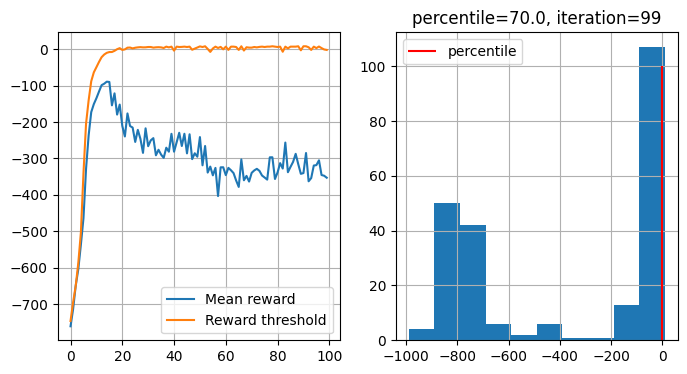

In [17]:
times_by_percentile = {}
percentiles = [10, 25, 40, 50, 70]
num_iterations = 100
rewards_by_percentile = {}

for p in percentiles:
    env.reset(seed=0)
    policy = initialize_policy(n_states, n_actions)
    policy, rewards, times = train_agent(env, policy, n_sessions, p, learning_rate, num_iterations)
    times_by_percentile[p] = times
    rewards_by_percentile[p] = rewards

In [18]:
def plot_by_percentiles(times_by_percentile, rewards_by_percentile, percentiles):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for p in percentiles:
        axes[0].plot(times_by_percentile[p], label=f"percentile={p}")
    axes[0].set_title("Training time by percentile")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Time, sec")
    axes[0].grid(True)
    axes[0].legend()

    for p in percentiles:
        arr = np.array(rewards_by_percentile[p])
        axes[1].plot(arr[:, 0], label=f"percentile={p}")
    axes[1].set_title("Mean reward by percentile")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Mean reward")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def plot_by_n_sessions(times_by_n_sessions, rewards_by_n_sessions, n_sessions):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for n in n_sessions:
        axes[0].plot(times_by_n_sessions[n], label=f"n_sessions={n}")
    axes[0].set_title("Training time by number of sessions")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Time, sec")
    axes[0].grid(True)
    axes[0].legend()

    for n in n_sessions:
        arr = np.array(rewards_by_n_sessions[n])
        axes[1].plot(arr[:, 0], label=f"n_sessions={n}")
    axes[1].set_title("Mean reward by number of sessions")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Mean reward")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

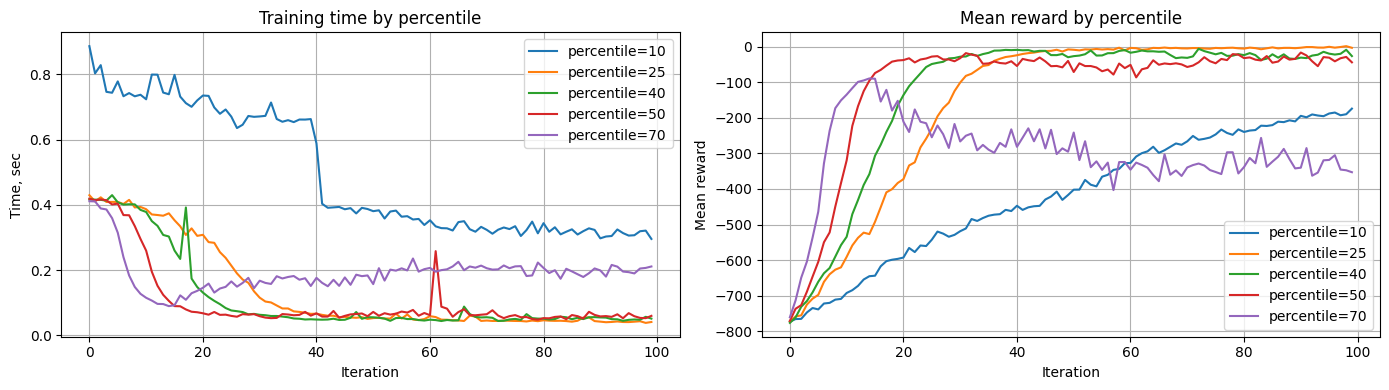

In [19]:
plot_by_percentiles(times_by_percentile, rewards_by_percentile, percentiles)

Перцинтиль 40 и 25 имеют самую быструю скорость операции в последствии. Кроме того, награда у них больше всего.

Надо будет сделать по шагам перцентиль.

mean reward = 0.197, threshold=5.000


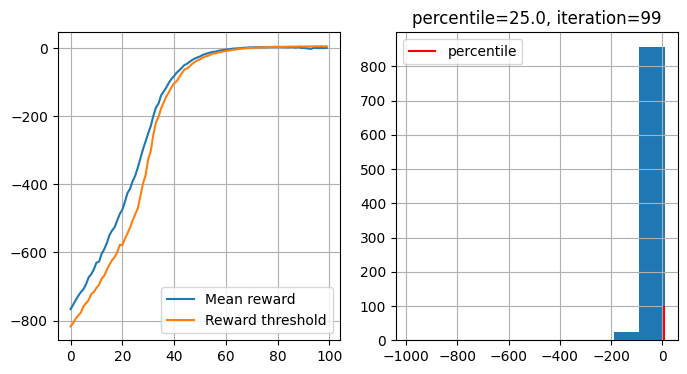

In [20]:
n_sessions = [100, 250, 500, 750, 1000]
times_by_n_sessions = {}
rewards_by_n_sessions = {}
percentile = 25
for n in n_sessions:
    env.reset(seed=0)
    policy = initialize_policy(n_states, n_actions)
    policy, rewards, times = train_agent(env, policy, n, percentile, learning_rate, num_iterations)
    times_by_n_sessions[n] = times
    rewards_by_n_sessions[n] = rewards

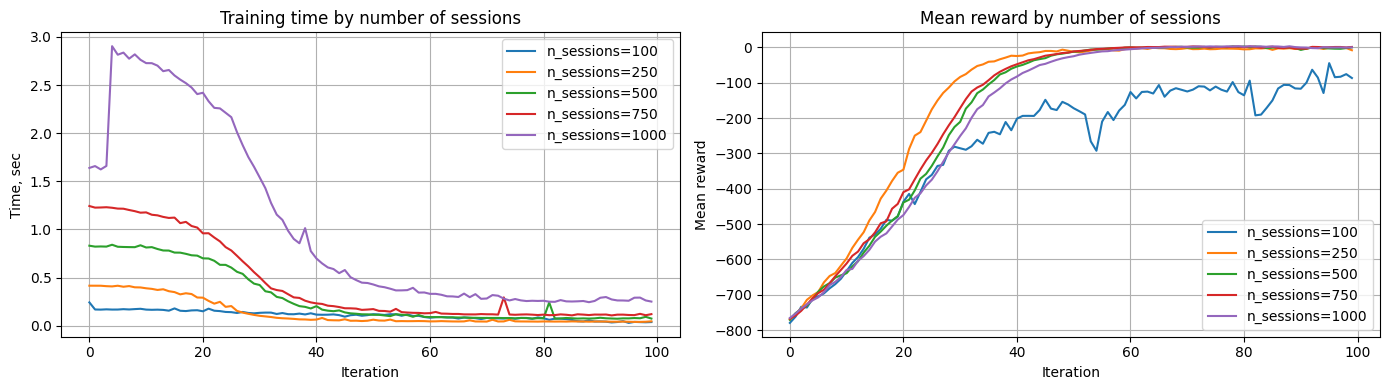

In [21]:
plot_by_n_sessions(times_by_n_sessions, rewards_by_n_sessions, n_sessions)

возьмем 250 сессий как баланс между скоростью и наградой

mean reward = 6.367, threshold=4.667


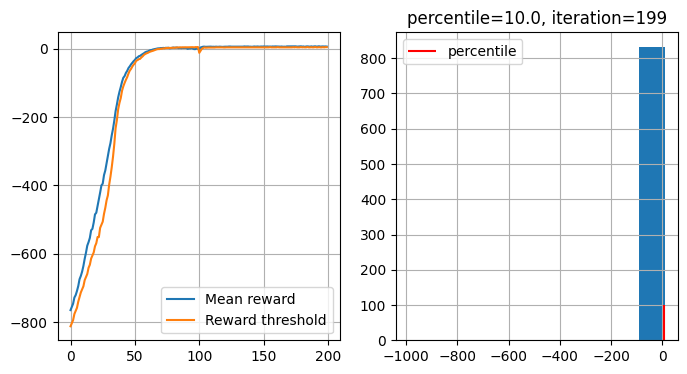

In [22]:
percentile = 25
n_sessions = 1000
num_iterations = 200

politik_percentile = [percentile] * (num_iterations // 2) + [10] * (num_iterations // 2)

env.reset(seed=0)

policy = initialize_policy(n_states, n_actions)
policy, rewards, times = train_agent(env, policy, n_sessions, percentile, learning_rate, num_iterations, politik_percentile=politik_percentile)

In [23]:
save_agent(policy, "taxi-v3_policy.pkl")
env.close()

Вывод: получили положительную среднюю награду, а если учитывать что максимальная средняя награда 20(если сразу подобрать и высадить), а тк надо ехать то 15 - получение награды в 6+ уже говорит о достаточно хорошем разумном поведении политики.

# Homework part II

### Deep crossentropy method

By this moment, you should have got enough score on [CartPole-v0](https://gymnasium.farama.org/environments/classic_control/cart_pole/) to consider it solved (see the link). It's time to try something harder.

* if you have any trouble with CartPole-v0 and feel stuck, feel free to ask us or your peers for help.

### Tasks

* __2.1__ (3 pts) Pick one of environments: `MountainCar-v0` or `LunarLander-v2`.
  * For MountainCar, get average reward of __at least -150__
  * For LunarLander, get average reward of __at least +50__

See the tips section below, it's kinda important.
__Note:__ If your agent is below the target score, you'll still get some of the points depending on the result, so don't be afraid to submit it.
  
  
* __2.2__ (up to 6 pts) Devise a way to speed up training against the default version
  * Obvious improvement: use [`joblib`](https://joblib.readthedocs.io/en/latest/). However, note that you will probably need to spawn a new environment in each of the workers instead of passing it via pickling. (2 pts)
  * Try re-using samples from 3-5 last iterations when computing threshold and training. (2 pts)
  * Obtain __-100__ at `MountainCar-v0` or __+200__ at `LunarLander-v2` (2 pts). Feel free to experiment with hyperparameters, architectures, schedules etc.
  
__Please list what you did in Anytask submission form__. This reduces probability that somebody misses something.
  
  
### Tips
* Gymnasium pages: [MountainCar](https://gymnasium.farama.org/environments/classic_control/mountain_car/), [LunarLander](https://gymnasium.farama.org/environments/box2d/lunar_lander/)
* Sessions for MountainCar may last for 10k+ ticks. Make sure ```t_max``` param is at least 10k.
 * Also it may be a good idea to cut rewards via ">" and not ">=". If 90% of your sessions get reward of -10k and 10% are better, than if you use percentile 20% as threshold, R >= threshold __fails to cut off bad sessions__ while R > threshold works alright.
* _issue with gym_: Some versions of gym limit game time by 200 ticks. This will prevent cem training in most cases. Make sure your agent is able to play for the specified __t_max__, and if it isn't, try `env = gym.make("MountainCar-v0").env` or otherwise get rid of TimeLimit wrapper.
* If you use old _swig_ lib for LunarLander-v2, you may get an error. See this [issue](https://github.com/openai/gym/issues/100) for solution.
* If it doesn't train, it's a good idea to plot reward distribution and record sessions: they may give you some clue. If they don't, call course staff :)
* 20-neuron network is probably not enough, feel free to experiment.

You may find the following snippet useful:

### Пункт 2.1

Делаю обычный MLPClassifaier для -150+ mean_reward

In [24]:
def visualize_mountain_car(env, agent):
    base_env = env.unwrapped  # unwrap wrappers to access MountainCar internals

    xs = np.linspace(base_env.min_position, base_env.max_position, 100)
    vs = np.linspace(-base_env.max_speed, base_env.max_speed, 100)

    grid = np.dstack(np.meshgrid(xs, vs[::-1])).transpose(1, 0, 2)
    grid_flat = grid.reshape(len(xs) * len(vs), 2)
    probs = agent.predict_proba(grid_flat).reshape(len(xs), len(vs), 3).transpose(1, 0, 2)

    f, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(
        probs,
        extent=(base_env.min_position, base_env.max_position, -base_env.max_speed, base_env.max_speed),
        aspect="auto",
    )
    ax.set_title("Learned policy: red=left, green=nothing, blue=right")
    ax.set_xlabel("position (x)")
    ax.set_ylabel("velocity (v)")

    states, actions, _ = generate_session(env, agent)
    states = np.array(states)
    ax.plot(states[:, 0], states[:, 1], color="white")

    for (x, v), a in zip(states[::3], actions[::3]):
        if a == 0:
            plt.arrow(x, v, -0.1, 0, color="white", head_length=0.02)
        elif a == 2:
            plt.arrow(x, v, 0.1, 0, color="white", head_length=0.02)

# with gym.make("MountainCar-v0", render_mode="human").env as env:
#     visualize_mountain_car(env, agent)


state vector dim = 2
n_actions = 3


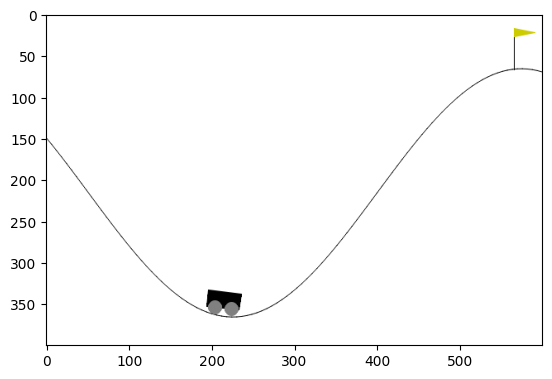

In [6]:
env = gym.make("MountainCar-v0", render_mode="rgb_array").env

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("n_actions =", n_actions)

# env.close()

In [ ]:
def select_elites(states_batch, actions_batch, rewards_batch, border_session, percentile=50):
    rewards_treshold = np.percentile(rewards_batch, percentile)
    elite_states = []
    elite_actions = []
    for states, actions, reward in zip(states_batch, actions_batch, rewards_batch):
        if reward > rewards_treshold and reward > border_session:
            elite_states.extend(states)
            elite_actions.extend(actions)
    return elite_states, elite_actions



def train_mountain_car_without_parallel(env, agent, n_sessions, percentile, log, num_iterations=100, t_max=10000):
    for i in range(num_iterations):
        sessions = [generate_session(env, agent, t_max) for _ in range(n_sessions)]

        states_batch, actions_batch, rewards_batch = zip(*sessions)

        elite_states, elite_actions = select_elites(
            states_batch, actions_batch, 
            rewards_batch, t_max, percentile
        )
        agent.partial_fit(elite_states, elite_actions)
        show_progress(
            rewards_batch, log, percentile, 
            reward_range=[np.min(rewards_batch), np.max(rewards_batch)],
            iteration=i
        )
        log.append([np.mean(rewards_batch), np.percentile(rewards_batch, percentile)])



mean reward = -128.875, threshold=-129.300


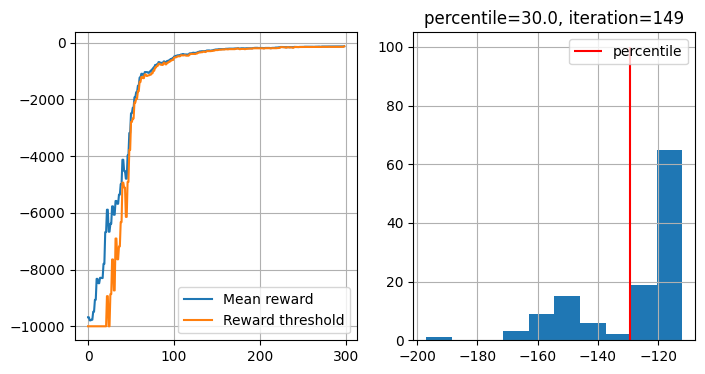

In [8]:
### пункт 2.1
n_sessions = 120
percentile = 30
log = []

agent = MLPClassifier(
    hidden_layer_sizes=(50, 40, 20),
    activation="tanh",
)

agent.partial_fit([env.reset()[0]] * n_actions, np.arange(n_actions), classes=np.arange(n_actions))

train_mountain_car_without_parallel(env, agent, n_sessions, percentile, log, num_iterations=150)

In [28]:
sessions = [generate_session(env, agent, 10000) for _ in range(n_sessions)]
_, _, rewards_batch = zip(*sessions)
save_agent(agent, "MountainCar-v0-2.1.pkl")
np.mean(rewards_batch), np.percentile(rewards_batch, percentile)

(np.float64(-138.075), np.float64(-142.0))

In [29]:
env.close()

Вывод: пробил обычной сеточкой, которая поглубже и вероятно смогла лучше запомнить распределение состояний и вариантов разных пробить порог в -150+, за 20м обучения.

### Пункт 2.2.1-2.2.3

- параллелю генерацию сессий в `generate_session_parallel`
- использую window_size для отбора элитных сессий(чтобы убрать деградацию и стараться улучшить результат только)
- пробиваем -95 на машинке

In [11]:
def generate_session_parallel(agent, game_name, t_max=10000):
    env_worker = gym.make(game_name, render_mode="rgb_array").env
    states, actions = [], []
    total_reward = 0.0

    s, _ = env_worker.reset()
    for _ in range(t_max):
        probs = agent.predict_proba([s])[0]
        a = np.random.choice(env_worker.action_space.n, p=probs)

        new_s, r, terminated, truncated, _ = env_worker.step(a)

        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break

    env_worker.close()
    return states, actions, total_reward

def train_mountain_car_parallel(agent, n_sessions, percentile, log,
                                num_iterations=100, max_steps=10000, 
                                step_progress=5, window_size=3,
                                game_name="MountainCar-v0",
                                finish_reward=-95):

    states_window = deque(maxlen=window_size)
    actions_window = deque(maxlen=window_size)
    rewards_window = deque(maxlen=window_size)

    for i in range(num_iterations):
        sessions = Parallel(n_jobs=-1)(
            delayed(generate_session_parallel)(agent, game_name, max_steps) for _ in range(n_sessions)
        )
        states_batch, actions_batch, rewards_batch = zip(*sessions)
        
        states_window.append(states_batch)
        actions_window.append(actions_batch)
        rewards_window.append(rewards_batch)

        flat_states = list(chain(*states_window))
        flat_actions = list(chain(*actions_window))
        flat_rewards = list(chain(*rewards_window))


        elite_states, elite_actions = select_elites(
            flat_states, flat_actions, flat_rewards, 
            -max_steps, percentile
        )

        
        if len(elite_states) > 0:
            agent.partial_fit(elite_states, elite_actions)
        

        if i % step_progress == 0:
            show_progress(
                rewards_batch, log, percentile, 
                reward_range=[np.min(rewards_batch), np.max(rewards_batch)],
                iteration=i
            )
        log.append([np.mean(rewards_batch), np.percentile(rewards_batch, percentile)])

        if np.mean(rewards_batch) > finish_reward:
            print(f"Успех! Средняя награда превысила {finish_reward}")
            break

In [9]:
agent = MLPClassifier(
    hidden_layer_sizes=(50, 30, 30, 20),
    activation="tanh",
)

agent.partial_fit([env.reset()[0]] * n_actions, np.arange(n_actions), classes=np.arange(n_actions))

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(50, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


mean reward = -125.930, threshold=-129.000


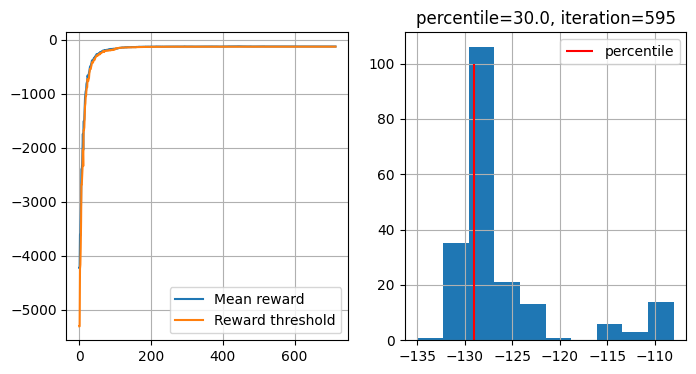

In [10]:
n_sessions = 200
percentile = 30
log = []

train_mountain_car_parallel(agent, n_sessions,
                            percentile, log,
                            num_iterations=600,
                            max_steps=10000,
                            window_size=3,
                            step_progress=5,
                            finish_reward=-95)

mean reward = -98.480, threshold=-103.000


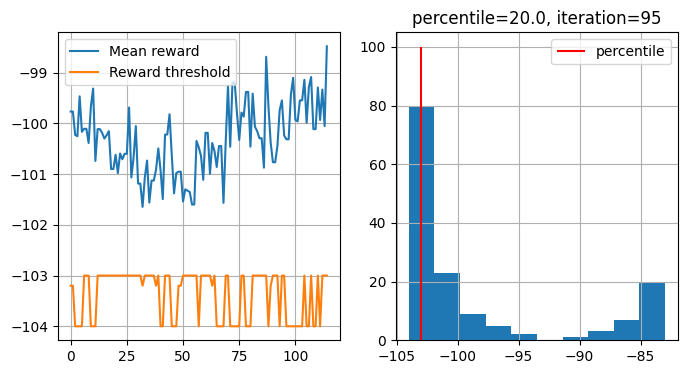

In [ ]:
# тк сессии уже хорошие идут, то дообучаем на большем числе хороших сессий, увеличив n_sessions и percentile
n_sessions = 150
percentile = 20
log = []

train_mountain_car_parallel(agent, n_sessions,
                            percentile, log,
                            num_iterations=100,
                            max_steps=105,
                            window_size=3,
                            step_progress=5,
                            finish_reward=-80)

In [29]:
sessions = [generate_session(env, agent, 10000) for _ in range(n_sessions)]
_, _, rewards_batch = zip(*sessions)
save_agent(agent, "MountainCar-v0-2.2.pkl")
np.mean(rewards_batch), np.percentile(rewards_batch, percentile)

(np.float64(-98.80666666666667), np.float64(-104.0))

Вывод: преодолел порог в -100, во 2 фазе обучения изменил перцентиль и число обучающих примеров

In [ ]:
## тестирование обученного агента
import numpy as np
from pickle import load

with open("MountainCar-v0-2.2.pkl", 'rb') as f:
    agent = load(f)

env = gym.make("MountainCar-v0", render_mode="rgb_array").env
sessions = [generate_session(env, agent, 10000) for _ in range(200)]
_, _, rewards_batch = zip(*sessions)
np.mean(rewards_batch), np.percentile(rewards_batch, 25)

(np.float64(-98.535), np.float64(-103.0))

### Bonus tasks

* __2.3 bonus__ (2 pts) Try to find a network architecture and training params that solve __both__ environments above (_Points depend on implementation. If you attempted this task, please mention it in Anytask submission._)

* __2.4 bonus__ (4 pts) Solve continuous action space task with `MLPRegressor` or similar.
  * Since your agent only predicts the "expected" action, you will have to add noise to ensure exploration.
  * Choose one of [MountainCarContinuous-v0](https://gymnasium.farama.org/environments/classic_control/mountain_car_continuous/) (90+ pts to solve), [LunarLanderContinuous-v2](https://gymnasium.farama.org/environments/box2d/lunar_lander/) (`env = gym.make("LunarLander-v2", continuous=True)`)(200+ pts to solve)
  * 4 points for solving. Slightly less for getting some results below solution threshold. Note that discrete and continuous environments may have slightly different rules, aside from action spaces.

### Пункт 2.3

state vector dim = 8
n_actions = 4


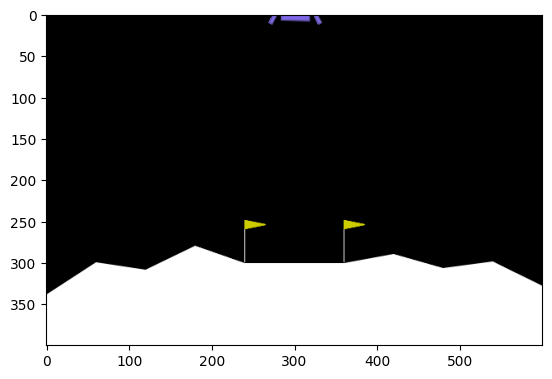

In [3]:
env = gym.make("LunarLander-v3", render_mode="rgb_array").env

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("n_actions =", n_actions)

# env.close()

In [4]:
env.step(0)

(array([ 0.0097476 ,  1.4281167 ,  0.49297777,  0.3692684 , -0.01116595,
        -0.11051466,  0.        ,  0.        ], dtype=float32),
 np.float64(0.2411793524711925),
 False,
 False,
 {})

In [5]:
def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10], iteration=None):
    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean reward")
    plt.plot(list(zip(*log))[1], label="Reward threshold")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.title("percentile=%.1f, iteration=%d" % (percentile, iteration), loc='center')
    plt.legend()
    plt.grid()
    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.show()

def generate_session_parallel(agent, game_name, t_max=10000):
    env_worker = gym.make(game_name, render_mode="rgb_array").env
    states, actions = [], []
    total_reward = 0.0
    lmbd = 0

    s, _ = env_worker.reset()
    for _ in range(t_max):
        probs = agent.predict_proba([s])[0]
        a = np.random.choice(env_worker.action_space.n, p=probs)

        new_s, r, terminated, truncated, _ = env_worker.step(a)

        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break

    env_worker.close()
    return states, actions, total_reward

def select_elites(states_batch, actions_batch, rewards_batch, border_session, percentile=50):
    rewards_treshold = np.percentile(rewards_batch, percentile)
    elite_states = []
    elite_actions = []
    for states, actions, reward in zip(states_batch, actions_batch, rewards_batch):
        if reward > rewards_treshold and reward > border_session:
            elite_states.extend(states)
            elite_actions.extend(actions)
    return elite_states, elite_actions

def get_percentile(i):
    if i <= 10:
        return 20
    if i <= 30:
        return 30
    if i <= 60:
        return 40
    if i <= 90:
        return 50
    if i <= 120:
        return 60    
    if i <= 150:
        return 70
    if i <= 170:
        return 80
    return 90

def train_lunar_lander_parallel(agent, n_sessions, log,
                                num_iterations=100, max_steps=10000, 
                                step_progress=5, window_size=3,
                                game_name="LunarLander-v2",
                                finish_reward=-95,
                                percentile_range=(20, 90)):

    states_window = deque(maxlen=window_size)
    actions_window = deque(maxlen=window_size)
    rewards_window = deque(maxlen=window_size)

    for i in range(num_iterations):
        current_percentile = percentile_range[0] + (percentile_range[1] - percentile_range[0]) * i / max(num_iterations - 1, 1)

        sessions = Parallel(n_jobs=-1)(
            delayed(generate_session_parallel)(agent, game_name, max_steps) for _ in range(n_sessions)
        )
        states_batch, actions_batch, rewards_batch = zip(*sessions)
        
        states_window.append(states_batch)
        actions_window.append(actions_batch)
        rewards_window.append(rewards_batch)

        flat_states = list(chain(*states_window))
        flat_actions = list(chain(*actions_window))
        flat_rewards = list(chain(*rewards_window))

        elite_states, elite_actions = select_elites(
            flat_states, flat_actions, flat_rewards, 
            -max_steps, current_percentile
        )

        if len(elite_states) > 0:
            agent.partial_fit(elite_states, elite_actions)

        if i % step_progress == 0:
            show_progress(
                rewards_batch, log, current_percentile, 
                reward_range=[np.min(rewards_batch), np.max(rewards_batch)],
                iteration=i
            )
        log.append([np.mean(rewards_batch), np.percentile(rewards_batch, current_percentile)])

        if np.mean(rewards_batch) > finish_reward:
            print(f"Успех! Средняя награда превысила {finish_reward}")
            break

In [ ]:
agent = MLPClassifier(
    hidden_layer_sizes=(50, 40, 30),
    activation="tanh",
)

agent.partial_fit([env.reset()[0]] * n_actions, np.arange(n_actions), classes=np.arange(n_actions))

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


mean reward = 56.237, threshold=104.924


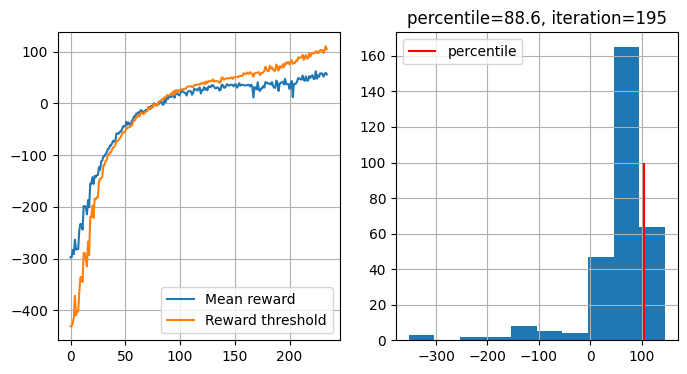

In [8]:
n_sessions = 300
log = []

train_lunar_lander_parallel(agent, n_sessions, log,
                            num_iterations=200,
                            max_steps=1000,
                            window_size=5,
                            step_progress=5,
                            finish_reward=210,
                            game_name="LunarLander-v3")

mean reward = 199.383, threshold=194.761


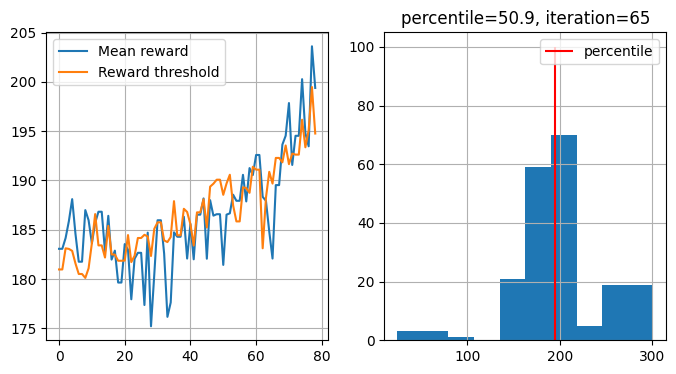

Успех! Средняя награда превысила 210


In [17]:
n_sessions = 200
log = []

train_lunar_lander_parallel(agent, n_sessions, log,
                            num_iterations=300,
                            max_steps=200,
                            window_size=4,
                            step_progress=5,
                            finish_reward=210,
                            game_name="LunarLander-v3",
                            percentile_range=(40, 90))

In [23]:
sessions = [generate_session(env, agent, 10000) for _ in range(n_sessions)]
_, _, rewards_batch = zip(*sessions)
save_agent(agent, "LunarLanding-v3.pkl")
np.mean(rewards_batch), np.percentile(rewards_batch, 75)

(np.float64(279.72175431689476), np.float64(303.428067392346))

Вывод: кажется хорошо обучили по схожей технологии, просто скачок незамеченным на графике остался.

In [ ]:
import numpy as np
from pickle import load

with open("LunarLanding-v3.pkl", 'rb') as f:
    agent = load(f)

env = gym.make("LunarLander-v3", render_mode="rgb_array").env
sessions = [generate_session(env, agent, 10000) for _ in range(200)]
_, _, rewards_batch = zip(*sessions)
np.mean(rewards_batch), np.percentile(rewards_batch, 25)

(np.float64(277.8325185758156), np.float64(269.59886083994354))

Вот и запущенный агент протестирован и все нормально